# 5.1 — The Forward Pass, at the computer

Do the **pen-and-paper worksheet first**. This notebook is where you check your hand trace,
meet the activations as *graphs*, and see what an untrained network thinks about the entire plane.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")   # lets Python find our shared plotting helpers

import numpy as np                  # the ML workhorse (Module 2 onwards)
import matplotlib.pyplot as plt
from plots import plot_functions

## 1. Meet the activations as shapes (Module 1.2 style)

Before any network: look at the two squashing functions from the lesson.
ReLU is a hinge; sigmoid is the S-curve you met in Module 1.5.

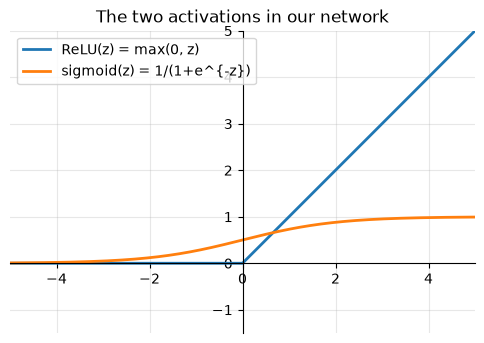

In [2]:
ax = plot_functions({
    "ReLU(z) = max(0, z)":        lambda z: np.maximum(0, z),
    "sigmoid(z) = 1/(1+e^{-z})":  lambda z: 1 / (1 + np.exp(-z)),
}, xlim=(-5, 5), ylim=(-1.5, 5))
ax.set_title("The two activations in our network")
plt.show()
# Read the shapes: ReLU kills everything left of 0. Sigmoid squashes ALL of z into (0, 1).

## 2. The lesson's network, one named move at a time

$\mathbf{x} = \begin{pmatrix}1\\2\end{pmatrix}$ through the 2-2-1 network. Every line below is a
move you did on paper — check each printed number against your trace.

In [3]:
x  = np.array([1.0, 2.0])
W1 = np.array([[0.5, -1.0],
               [1.0,  0.5]])
b1 = np.array([0.5, -1.0])
W2 = np.array([-1.0, 2.0])
b2 = -2.0

z1 = W1 @ x + b1              # matrix multiply (Module 2.5) + bias shift (Module 1.3)
h  = np.maximum(0, z1)        # ReLU activation — elementwise max against 0
z2 = W2 @ h + b2              # same two moves, second layer
y_hat = 1 / (1 + np.exp(-z2)) # sigmoid (Module 1.5): squash into a probability

print("z1    =", z1)          # expect [-1.  1.]
print("h     =", h)           # expect [0. 1.]  <- neuron 1 switched off
print("z2    =", z2)          # expect 0.0
print("y_hat =", y_hat)       # expect 0.5 — the fifty-fifty shrug

z1    = [-1.  1.]
h     = [0. 1.]
z2    = 0.0
y_hat = 0.5


## 3. Package it: a network is a composed function (Module 1.4)

On paper the forward pass felt like five steps. In code it's one function calling tiny functions —
machines feeding machines. **We reuse this exact function in notebooks 02–04.**

In [4]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    h  = relu(z1)
    z2 = W2 @ h + b2
    y_hat = sigmoid(z2)
    return z1, h, z2, y_hat      # return ALL of them — backprop (5.3) will need the middles

z1, h, z2, y_hat = forward(x, W1, b1, W2, b2)
print("composed answer:", y_hat)   # same 0.5 — g(f(x)), wearing a trench coat

composed answer: 0.5


In [5]:
# YOUR TURN — check your worksheet Part B trace (x=(2,1) network).
# Fill in the worksheet's weights, run, and compare with your handwriting.

Wb1 = np.array([[1.0, -2.0],
                [0.5,  1.0]])
bb1 = np.array([1.0, -2.0])
Wb2 = np.array([3.0, -1.0])
bb2 = -2.0

xb = np.array([2.0, 1.0])
print(forward(xb, Wb1, bb1, Wb2, bb2))

# Then: worksheet problem 8 used x = (0, 2). Predict all four values BEFORE you run it here.
# Finally, invent an input that wakes the lesson network's dead neuron 1 (worksheet problem 13)
# and confirm h[0] > 0.

(array([1., 0.]), array([1., 0.]), np.float64(1.0), np.float64(0.7310585786300049))


## 4. What does the network think about the WHOLE plane?

Your hand trace was one input. numpy can push *every* point of the plane through the network at
once and colour it by the output. This picture is called a **decision surface** — remember it,
because in notebook 04 you'll watch one of these *learn*.

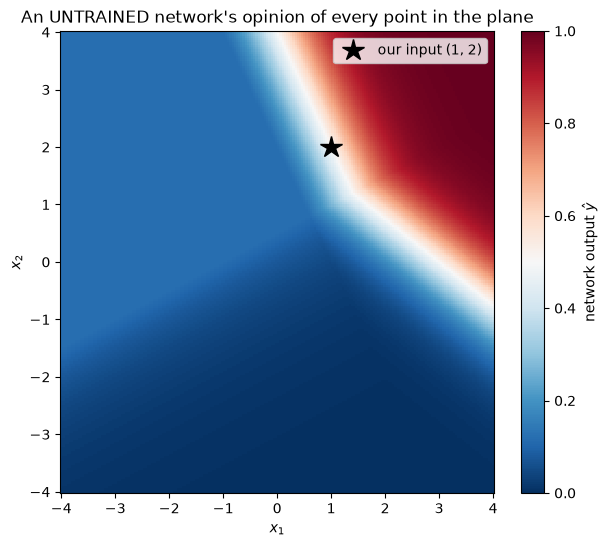

In [6]:
# np.meshgrid builds a grid of coordinates: every combination of xs and ys (new syntax!)
xs = np.linspace(-4, 4, 200)
ys = np.linspace(-4, 4, 200)
gx, gy = np.meshgrid(xs, ys)

# Push all 40,000 points through at once — the same math, batched
Z1a = 0.5 * gx - 1.0 * gy + 0.5     # hidden neuron 1's z, everywhere
Z1b = 1.0 * gx + 0.5 * gy - 1.0     # hidden neuron 2's z, everywhere
H1, H2 = np.maximum(0, Z1a), np.maximum(0, Z1b)
out = 1 / (1 + np.exp(-(-1.0 * H1 + 2.0 * H2 - 2.0)))

plt.figure(figsize=(7, 6))
plt.pcolormesh(gx, gy, out, cmap="RdBu_r", vmin=0, vmax=1, shading="auto")
plt.colorbar(label="network output $\\hat{y}$")
plt.plot(1, 2, "k*", markersize=16, label="our input (1, 2)")
plt.title("An UNTRAINED network's opinion of every point in the plane")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend()
plt.show()
# The creases in the colour are exactly where each ReLU switches on/off —
# the boundary you described in worksheet problem 13 is visible right here.

The network already carves the plane into regions — with *arbitrary* weights it's just carving
in the wrong places. Everything from here to notebook 04 is about moving those creases to where
the data says they should be.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude.
Next: 5.2 — scoring how wrong we are.*